In [1]:
from scoresbibm.src.utils.data_utils import query, get_summary_df,load_model
from scoresbibm.src.utils.plot import plot_metric_by_num_simulations, use_style,multi_plot

from scoresbibm.src.tasks.unstructured_tasks import LotkaVolterraTask

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

/mnt/qb/work/macke/mgloeckler90/miniconda3/envs/probjax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEFAULT_COLORS = {"npe": "#154c79", "nle": "#1e81b0", "nre": "#76b5c5", "nspe": "#fdae61", "score_transformer": "#d73027", "score_transformer_posterior": "#8b27d7", "score_transformer_directed": "#f25d1d","score_transformer_min_graphical": "#f25d1d", "score_transformer_undirected": "#911c1c", "score_transformer_graphical": "#911c1c"}
figsize_per_row = 1.75
figsize_per_col = 2.

COLOR_PREDATOR = "firebrick"
COLOR_PREY = "seagreen"
COLOR_PARAMETER = "navy"

In [3]:
with use_style("pyloric"):
    fig, axes = multi_plot("../../results/bm_lotka_volterra", "task", "metric", plot_metric_by_num_simulations, hue="method", color_map=DEFAULT_COLORS, figsize_per_row=figsize_per_row, figsize_per_col=figsize_per_col, legend_ncol=4, method_sde_name="vesde")
    legend = fig.legends[-1]
    axes[0,0].set_title("")
    fig.legends = []
    fig.savefig("bm_lv.svg")
    plt.show()

ValueError: cannot call `vectorize` on size 0 inputs unless `otypes` is set

/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/data_utils.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q["value"] = df_q["value"].apply(lambda x: np.array(eval(x)))
/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/data_utils.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q["value"] = df_q["value"].apply(lambda x: np.mean(x))
/mnt/qb/work/macke/mgloeckler90/probjax/scoresbibm/src/utils/plot.py:390: UserWarning: The figure layout has changed to tight
  fig.tight_l

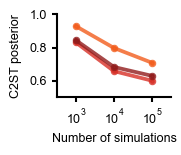

In [270]:
with use_style("pyloric"):
    # FAKE data
    fig, axes = multi_plot("../../results/main_benchmark_lv_large", "task", "metric", plot_metric_by_num_simulations, hue="method", color_map=DEFAULT_COLORS, figsize_per_row=figsize_per_row, figsize_per_col=figsize_per_col, legend_ncol=4, method_sde_name="vesde")
    legend = fig.legends[-1]
    fig.legends = []
    axes[0,0].set_title("")
    axes[0,0].set_ylabel("C2ST posterior")
    fig.savefig("bm_lv_posterior.svg")
    plt.show()

/tmp/ipykernel_70012/1714786348.py:5: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  fig.legend(ncol=1, handles=legend.legendHandles, labels=["  NSCE", "  NSCE\n (directed graph)", "  NSCE\n (undirected graph)"], loc="center", bbox_to_anchor=(0., 0.5))


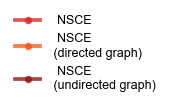

In [273]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(1,0.2))
    ax = plt.gca()
    plt.axis("off")
    fig.legend(ncol=1, handles=legend.legendHandles, labels=["  NSCE", "  NSCE\n (directed graph)", "  NSCE\n (undirected graph)"], loc="center", bbox_to_anchor=(0., 0.5))
    
    fig.savefig("method_legend.svg", transparent=True, bbox_inches="tight")
    plt.show()

In [241]:
legend._ncol

1

In [302]:
task = LotkaVolterraTask()

observation_generator = task.get_observation_generator()
reference_sampler = task.get_reference_sampler()
observation_stream = observation_generator(jax.random.PRNGKey(5))

In [5]:
query("../../results/main_benchmark_lv_large", num_simulations=100000, method_sde_name="vesde", metric="c2st")

,method,task,num_simulations,seed,model_id,metric,value,time_train,time_eval,cfg
11,score_transformer,lotka_volterra,100000,0,11,c2st,0.59990,4274.579641,9.269728,"{'name': 'main_benchmark_lv_large', 'seed': 0,..."
12,score_transformer_directed,lotka_volterra,100000,0,12,c2st,0.70785,4667.575593,8.708626,"{'name': 'main_benchmark_lv_large', 'seed': 0,..."
17,score_transformer_undirected,lotka_volterra,100000,0,17,c2st,0.62910,4523.318177,10.912443,"{'name': 'main_benchmark_lv_large', 'seed': 0,..."


In [6]:
model = load_model("../../results/main_benchmark_lv_large", 11)

In [303]:
num_time_points = 200
node_id = jnp.array([0,1,2,3] + [4]*num_time_points + [5]*num_time_points)
time_grid = jnp.linspace(0, 15, num_time_points)
meta_data = jnp.concatenate([jnp.full((4,), jnp.nan), time_grid,time_grid])
condition_mask_posterior = jnp.array([False]*4 + [False]*num_time_points + [False]*num_time_points)
x_o = jnp.array([])

In [304]:
_, _, xs, meta_data, _ = next(observation_stream)

In [305]:
_, ts_o1, ts_o2 = jnp.split(meta_data, [4, 24])

In [306]:

index1 = jnp.searchsorted(time_grid, ts_o1)[:4]
time_grid = time_grid.at[index1].set(ts_o1[:4])
meta_data = jnp.concatenate([jnp.full((4,), jnp.nan), time_grid,time_grid])
condition_mask_posterior = condition_mask_posterior.at[4 + index1].set(True)
x_o = xs[4:8]

In [307]:
posterior_and_predictive = model.sample(1000, x_o=x_o, condition_mask=condition_mask_posterior, node_id=node_id, meta_data=meta_data, rng=jax.random.PRNGKey(0), return_conditioned_samples=True)

In [308]:
thetas, predator,prey = jnp.split(posterior_and_predictive, [4,4+num_time_points], axis=1)
_,condition_mask_predator, condition_mask_prey = jnp.split(condition_mask_posterior, [4,4+num_time_points])
mean_predator = jnp.mean(predator, axis=0)[~condition_mask_predator]
q_l = jnp.percentile(predator, 0.5, axis=0)[~condition_mask_predator]
q_u = jnp.percentile(predator, 99.5, axis=0)[~condition_mask_predator]

mean_prey = jnp.mean(prey, axis=0)[~condition_mask_prey]
q_l_prey = jnp.percentile(prey, 0.5, axis=0)[~condition_mask_prey]
q_u_prey = jnp.percentile(prey, 99.5, axis=0)[~condition_mask_prey]

# Smooth mean and quantiles using jax scipy signal 
from scipy.signal import savgol_filter
mean_predator = savgol_filter(mean_predator, 12, 3)
q_l = savgol_filter(q_l, 12, 3)
q_u = savgol_filter(q_u, 12, 3)

mean_prey = savgol_filter(mean_prey, 12, 3)
q_l_prey = savgol_filter(q_l_prey, 12, 3)
q_u_prey = savgol_filter(q_u_prey, 12, 3)



In [309]:
import matplotlib.gridspec as gridspec
import seaborn as sns

/tmp/ipykernel_70012/3219670264.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  _ = sns.kdeplot(thetas[:,0], ax=ax1, color=COLOR_PARAMETER, shade=True)
/tmp/ipykernel_70012/3219670264.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(thetas[:,i], ax=ax, color=COLOR_PARAMETER, shade=True)
/tmp/ipykernel_70012/3219670264.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(thetas[:,i], ax=ax, color=COLOR_PARAMETER, shade=True)
/tmp/ipykernel_70012/3219670264.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

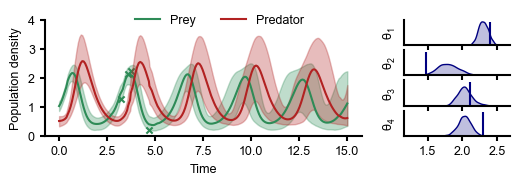

In [310]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(6, 1.5))
    gs = gridspec.GridSpec(4, 2, width_ratios=[3, 1])
    ax0 = plt.subplot(gs[:, 0])
    _ = ax0.scatter(ts_o1[:4], x_o[:4], color=COLOR_PREY, marker="x", s=20)
    l1 = ax0.plot(time_grid[~condition_mask_predator], mean_predator, color=COLOR_PREY, label="Prey")
    _ = ax0.fill_between(time_grid[~condition_mask_predator], q_l, q_u, alpha=0.3, color=COLOR_PREY)

    #_= ax0.scatter(ts_o2[10:], x_o[3:], color="C1", marker="x", s=20)
    l2 = ax0.plot(time_grid[~condition_mask_prey], mean_prey, color=COLOR_PREDATOR, label="Predator")
    _ = ax0.fill_between(time_grid[~condition_mask_prey], q_l_prey, q_u_prey, alpha=0.3, color=COLOR_PREDATOR)
    
    ax0.set_xlabel("Time")
    ax0.set_ylabel("Population density")
    ax0.set_ylim(0,4)
    ax0.legend(handles=[l1[0],l2[0]], ncols=2, bbox_to_anchor=(0.25,0.85))
    
    ax1 = plt.subplot(gs[0, 1])
    _ = sns.kdeplot(thetas[:,0], ax=ax1, color=COLOR_PARAMETER, shade=True)
    ax1.vlines(xs[0], 0, 5, color=COLOR_PARAMETER)
    ax1.set_ylabel(r"$\theta_1$")
    ax1.set_yticks([])
    for i in range(1,4):
        ax = plt.subplot(gs[i, 1], sharex=ax1)
        ax = sns.kdeplot(thetas[:,i], ax=ax, color=COLOR_PARAMETER, shade=True)
        ax.set_ylabel(r"$\theta_{}$".format(i+1))
        ax.vlines(xs[i], 0, 5, color=COLOR_PARAMETER)
        ax.set_yticks([])

    fig.savefig("lv_few_observations.svg")
    plt.show()


In [311]:
index2 = jnp.searchsorted(time_grid, ts_o2)[10:]
time_grid = time_grid.at[index2].set(ts_o2[10:])
meta_data = jnp.concatenate([jnp.full((4,), jnp.nan), time_grid,time_grid])
condition_mask_posterior = condition_mask_posterior.at[4 + num_time_points + index2].set(True)
x_o = jnp.concatenate([x_o, xs[4 + 20 + 10:]])

In [312]:
print(x_o.shape, condition_mask_posterior.sum(), meta_data.shape)

(14,) 14 (404,)


In [313]:
posterior_and_predictive2 = model.sample(1000, x_o=x_o, condition_mask=condition_mask_posterior, node_id=node_id, meta_data=meta_data, rng=jax.random.PRNGKey(0), return_conditioned_samples=True)

In [314]:
thetas, predator,prey = jnp.split(posterior_and_predictive2, [4,4+num_time_points], axis=1)
_,condition_mask_predator, condition_mask_prey = jnp.split(condition_mask_posterior, [4,4+num_time_points])
mean_predator2 = jnp.mean(predator, axis=0)[~condition_mask_predator]
q_l2 = jnp.percentile(predator, 0.5, axis=0)[~condition_mask_predator]
q_u2 = jnp.percentile(predator, 99.5, axis=0)[~condition_mask_predator]

mean_prey2 = jnp.mean(prey, axis=0)[~condition_mask_prey]
q_l_prey2 = jnp.percentile(prey, 0.5, axis=0)[~condition_mask_prey]
q_u_prey2 = jnp.percentile(prey, 99.5, axis=0)[~condition_mask_prey]

# Smooth mean and quantiles using jax scipy signal 
from scipy.signal import savgol_filter
mean_predator2 = savgol_filter(mean_predator2, 12, 3)
q_l2 = savgol_filter(q_l2, 12, 3)
q_u2 = savgol_filter(q_u2, 12, 3)

mean_prey2 = savgol_filter(mean_prey2, 12, 3)
q_l_prey2 = savgol_filter(q_l_prey2, 12, 3)
q_u_prey2 = savgol_filter(q_u_prey2, 12, 3)



In [315]:
import matplotlib.gridspec as gridspec
import seaborn as sns

/tmp/ipykernel_70012/112577861.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  _ = sns.kdeplot(thetas[:,0], ax=ax1, color=COLOR_PARAMETER, shade=True)
/tmp/ipykernel_70012/112577861.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(thetas[:,i], ax=ax, color=COLOR_PARAMETER, shade=True)
/tmp/ipykernel_70012/112577861.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(thetas[:,i], ax=ax, color=COLOR_PARAMETER, shade=True)
/tmp/ipykernel_70012/112577861.py:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  

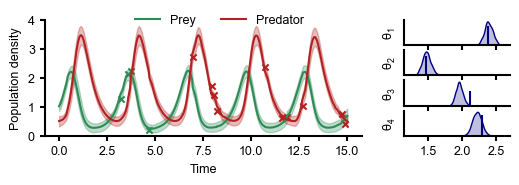

In [316]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(6, 1.5))
    gs = gridspec.GridSpec(4, 2, width_ratios=[3, 1])
    ax0 = plt.subplot(gs[:, 0])
    _ = ax0.scatter(ts_o1[:4], x_o[:4], color=COLOR_PREY, marker="x", s=20)
    l1 = ax0.plot(time_grid[~condition_mask_predator], mean_predator2, color=COLOR_PREY, label="Prey")
    _ = ax0.fill_between(time_grid[~condition_mask_predator], q_l2, q_u2, alpha=0.3, color=COLOR_PREY)

    _= ax0.scatter(ts_o2[10:], x_o[4:], color=COLOR_PREDATOR, marker="x", s=20)
    l2 = ax0.plot(time_grid[~condition_mask_prey], mean_prey2, color=COLOR_PREDATOR, label="Predator")
    _ = ax0.fill_between(time_grid[~condition_mask_prey], q_l_prey2, q_u_prey2, alpha=0.3, color=COLOR_PREDATOR)
    
    ax0.set_xlabel("Time")
    ax0.set_ylabel("Population density")
    ax0.set_ylim(0,4)
    ax0.legend(handles=[l1[0],l2[0]], ncols=2, bbox_to_anchor=(0.25,0.85))
    
    ax1 = plt.subplot(gs[0, 1])
    _ = sns.kdeplot(thetas[:,0], ax=ax1, color=COLOR_PARAMETER, shade=True)
    ax1.vlines(xs[0], 0, 5, color=COLOR_PARAMETER)
    ax1.set_ylabel(r"$\theta_1$")
    ax1.set_yticks([])
    for i in range(1,4):
        ax = plt.subplot(gs[i, 1], sharex=ax1)
        ax = sns.kdeplot(thetas[:,i], ax=ax, color=COLOR_PARAMETER, shade=True)
        ax.set_ylabel(r"$\theta_{}$".format(i+1))
        ax.vlines(xs[i], 0, 5, color=COLOR_PARAMETER)
        ax.set_yticks([])

    fig.savefig("lv_many_observations.svg")
    plt.show()


In [ ]:
posterior_samples = model.sample(1000, x_o=x_o, condition_mask=condition_mask, node_id=node_id, meta_data=meta_data, rng=jax.random.PRNGKey(0))

In [ ]:
ref_samples = reference_sampler.sample(1000, x_o=x_o, condition_mask=condition_mask, meta_data=meta_data, rng=jax.random.PRNGKey(0))

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

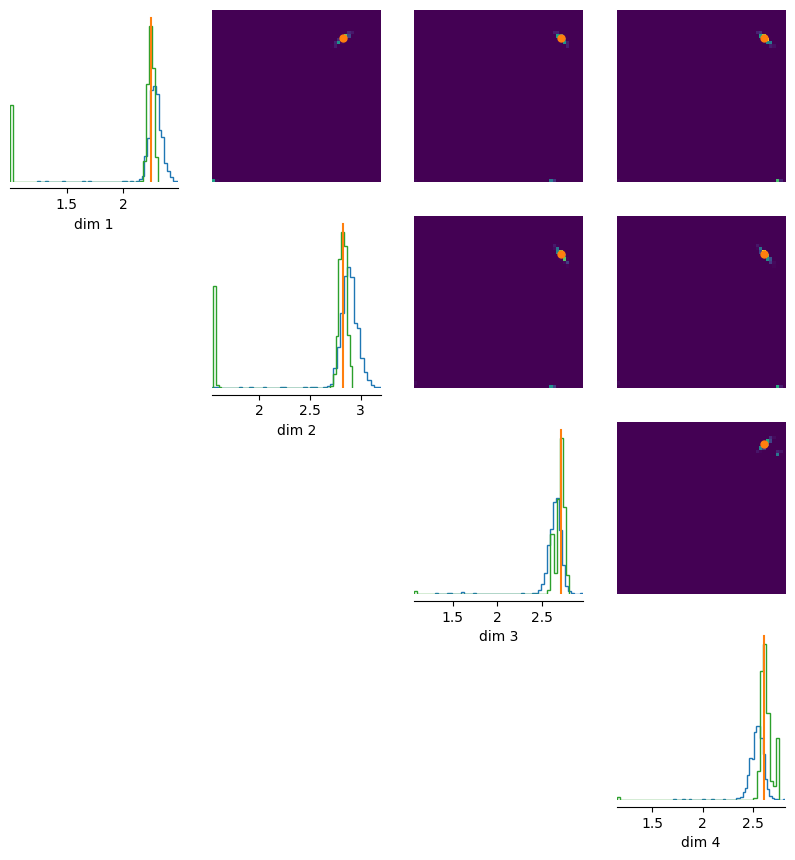

In [47]:
from sbi.analysis import pairplot
import numpy as np

pairplot([np.array(posterior_samples),np.array(ref_samples)], points=theta_o)